<a href="https://colab.research.google.com/github/AkashssA/MACHINE_LEARNING_2/blob/main/bagging_and_boosting_big_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
try:
    df = pd.read_csv('data.csv')
    print("Dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: data.csv not found. Please upload the file.")
    exit()

# Separate features (X) and target (y)
# Assuming the last column is the target variable
X = df.iloc[:, :-1]
y_continuous = df.iloc[:, -1] # Store original continuous target

# Convert continuous 'writing_score' to categorical bins for classification
# You can adjust the bins and labels based on your data distribution or problem requirements
bins = [0, 60, 80, 100] # Example: scores 0-59 (low), 60-79 (medium), 80-100 (high)
labels = ['low', 'medium', 'high']
y = pd.cut(y_continuous, bins=bins, labels=labels, include_lowest=True)
print(f"\nOriginal target variable 'writing_score' binned into: {y.unique()}")

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing for categorical features: One-Hot Encoding
# Preprocessing for numerical features: No scaling needed for tree-based models initially
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Encode target variable (which is now categorical after binning)
le = LabelEncoder()
y = le.fit_transform(y)
print(f"Target classes (encoded): {le.classes_}")

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Dataset loaded successfully.


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



Original target variable 'writing_score' binned into: ['medium', 'high', 'low']
Categories (3, object): ['low' < 'medium' < 'high']
Target classes (encoded): ['high' 'low' 'medium']

Training set shape: (700, 7)
Testing set shape: (300, 7)


In [8]:
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- Bagging Classifier ---
# Using Decision Tree as the base estimator, corrected to 'estimator'
bagging_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42, n_jobs=-1))])

print("Training Bagging Classifier...")
bagging_pipeline.fit(X_train, y_train)
y_pred_bagging = bagging_pipeline.predict(X_test)

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
print(f"\nBagging Classifier Accuracy: {accuracy_bagging:.4f}")
print("Bagging Classifier Classification Report:")
print(classification_report(y_test, y_pred_bagging, target_names=[str(cls) for cls in le.classes_]))

# --- Gradient Boosting Classifier ---
boosting_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))])

print("\nTraining Gradient Boosting Classifier...")
boosting_pipeline.fit(X_train, y_train)
y_pred_boosting = boosting_pipeline.predict(X_test)

accuracy_boosting = accuracy_score(y_test, y_pred_boosting)
print(f"\nGradient Boosting Classifier Accuracy: {accuracy_boosting:.4f}")
print("Gradient Boosting Classifier Classification Report:")
print(classification_report(y_test, y_pred_boosting, target_names=[str(cls) for cls in le.classes_]))

Training Bagging Classifier...

Bagging Classifier Accuracy: 0.8400
Bagging Classifier Classification Report:
              precision    recall  f1-score   support

        high       0.79      0.84      0.82        63
         low       0.88      0.86      0.87        90
      medium       0.84      0.83      0.84       147

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300


Training Gradient Boosting Classifier...

Gradient Boosting Classifier Accuracy: 0.8400
Gradient Boosting Classifier Classification Report:
              precision    recall  f1-score   support

        high       0.82      0.86      0.84        63
         low       0.86      0.83      0.85        90
      medium       0.84      0.84      0.84       147

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.8

/tmp/ipykernel_2516/501843877.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


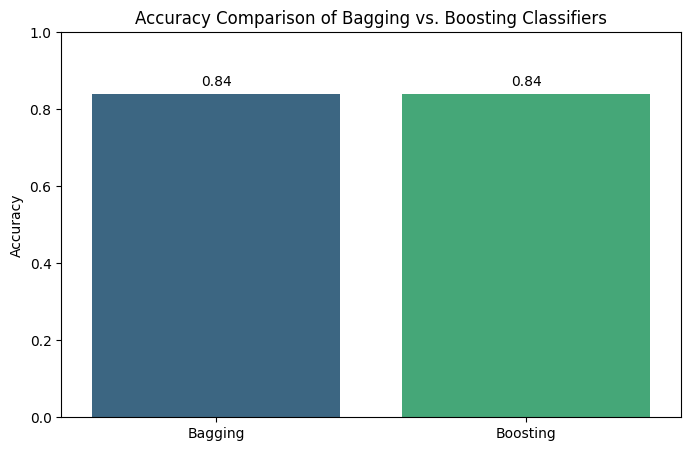

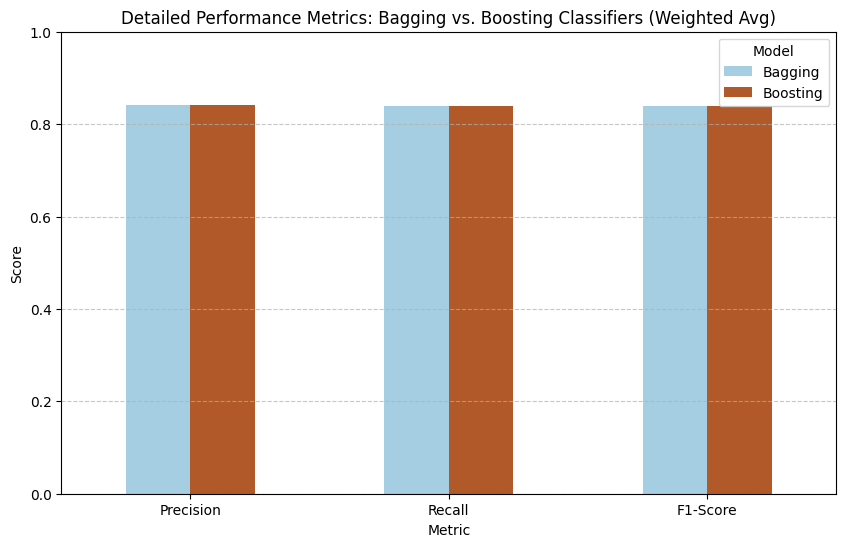

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
model_names = ['Bagging', 'Boosting']
accuracies = [accuracy_bagging, accuracy_boosting]

# --- Graph 1: Accuracy Comparison ---
fig1 = plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Accuracy Comparison of Bagging vs. Boosting Classifiers')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')
plt.show()

# Get classification reports as dictionaries
report_bagging = classification_report(y_test, y_pred_bagging, output_dict=True, zero_division=0)
report_boosting = classification_report(y_test, y_pred_boosting, output_dict=True, zero_division=0)

# Extract metrics for a specific class (e.g., class 0 or weighted avg for overall view)
# For simplicity, let's use 'weighted avg' if available, otherwise pick a class (e.g., the first one)
if 'weighted avg' in report_bagging:
    metrics_bagging = report_bagging['weighted avg']
    metrics_boosting = report_boosting['weighted avg']
    title_suffix = " (Weighted Avg)"
else:
    # If not a multi-class problem or specific classes are preferred, pick a class
    # Assuming binary classification, pick class '0' or adjust based on actual target classes
    target_class_key = str(0) # Assuming '0' is a class key, adjust if different
    metrics_bagging = report_bagging[target_class_key]
    metrics_boosting = report_boosting[target_class_key]
    title_suffix = f" (Class {target_class_key})"


metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Bagging': [metrics_bagging['precision'], metrics_bagging['recall'], metrics_bagging['f1-score']],
    'Boosting': [metrics_boosting['precision'], metrics_boosting['recall'], metrics_boosting['f1-score']]
})

# --- Graph 2: Detailed Metrics Comparison ---
fig2 = plt.figure(figsize=(10, 6))
metrics_df.set_index('Metric').plot(kind='bar', figsize=(10, 6), rot=0, ax=plt.gca(), cmap='Paired')
plt.title(f'Detailed Performance Metrics: Bagging vs. Boosting Classifiers{title_suffix}')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_2516/501843877.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


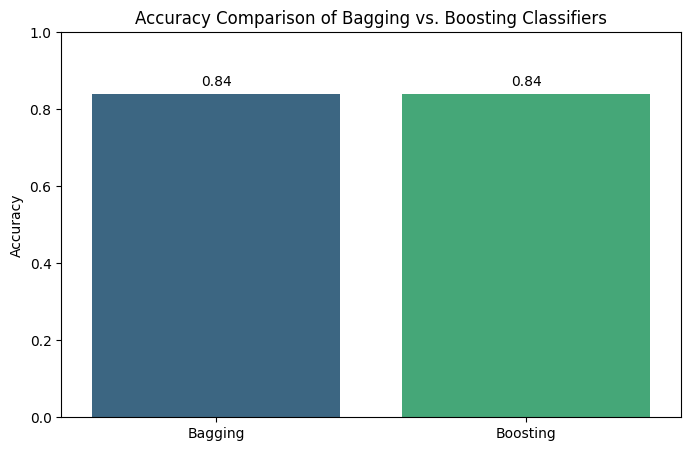

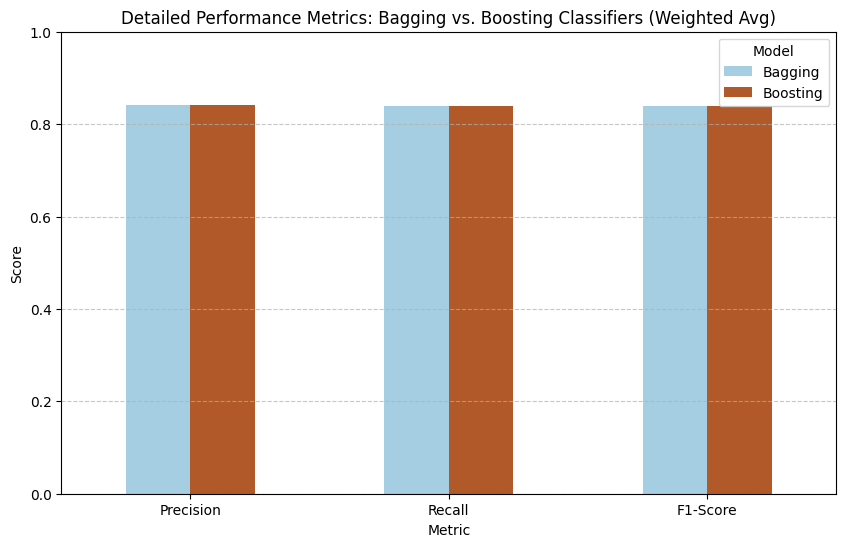

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
model_names = ['Bagging', 'Boosting']
accuracies = [accuracy_bagging, accuracy_boosting]

# --- Graph 1: Accuracy Comparison ---
fig1 = plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Accuracy Comparison of Bagging vs. Boosting Classifiers')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')
plt.show()

# Get classification reports as dictionaries
report_bagging = classification_report(y_test, y_pred_bagging, output_dict=True, zero_division=0)
report_boosting = classification_report(y_test, y_pred_boosting, output_dict=True, zero_division=0)

# Extract metrics for a specific class (e.g., class 0 or weighted avg for overall view)
# For simplicity, let's use 'weighted avg' if available, otherwise pick a class (e.g., the first one)
if 'weighted avg' in report_bagging:
    metrics_bagging = report_bagging['weighted avg']
    metrics_boosting = report_boosting['weighted avg']
    title_suffix = " (Weighted Avg)"
else:
    # If not a multi-class problem or specific classes are preferred, pick a class
    # Assuming binary classification, pick class '0' or adjust based on actual target classes
    target_class_key = str(0) # Assuming '0' is a class key, adjust if different
    metrics_bagging = report_bagging[target_class_key]
    metrics_boosting = report_boosting[target_class_key]
    title_suffix = f" (Class {target_class_key})"


metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Bagging': [metrics_bagging['precision'], metrics_bagging['recall'], metrics_bagging['f1-score']],
    'Boosting': [metrics_boosting['precision'], metrics_boosting['recall'], metrics_boosting['f1-score']]
})

# --- Graph 2: Detailed Metrics Comparison ---
fig2 = plt.figure(figsize=(10, 6))
metrics_df.set_index('Metric').plot(kind='bar', figsize=(10, 6), rot=0, ax=plt.gca(), cmap='Paired')
plt.title(f'Detailed Performance Metrics: Bagging vs. Boosting Classifiers{title_suffix}')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()